In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [2]:
def load_and_reshape_matrix(name, base_dir, ref_lat=38.10, ref_lon=20.20, dx=0.5, dz=0.5, nx=151, ny=151, nz=151):
    """
    Loads and reshapes a coherence matrix from an .npy file based on the provided parameters.
    
    Parameters:
        name (str): The event name (e.g., 'prlri').
        base_dir (str): The base directory containing the .npy files.
        ref_lat (float): Reference latitude.
        ref_lon (float): Reference longitude.
        dx (float): Grid step in latitude.
        dz (float): Grid step in longitude.
        nx (int): Grid size in x-direction.
        ny (int): Grid size in y-direction.
        nz (int): Grid size in z-direction.
    
    Returns:
        tuple: Reshaped numpy array and calculated latitude/lbola inquieta ma se è quello che vongitude ranges.
    """
    
    # Define file path

    # Define types
    types = ["station", "fibre", "hybrid", "hybrid_strain_to_vel"]

    file_path = []
    title = []

    # Loop to create paths
    for t in types:
        file_path.append(os.path.join(base_dir, f"{name}_{t}_coherence_matrix.npy"))
        title.append(f"{name} {t} coherence matrix")

    # Convert 50 km to degrees latitude and longitude
    km_to_deg = (nx * dx) / np.sqrt(2) / 111
    km_to_deg_lon = (nx * dx) / np.sqrt(2) / (111 * math.cos(math.radians(ref_lat)))
    
    # Compute lat/lon range
    lat_range = (ref_lat, ref_lat + km_to_deg)
    lon_range = (ref_lon, ref_lon + km_to_deg_lon)
    


    return file_path, title, lat_range, lon_range

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import pandas as pd

def cartesian_to_geographic(x, y, origin_lat, origin_lon):
    earth_radius = 6371  # Approximate Earth radius in km
    lat = origin_lat + (y / earth_radius) * (180 / np.pi)
    lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
    return lat, lon

def load_das_channels(csv_file):
    df = pd.read_csv(csv_file)
    das_channels = {row['channel_number_recorded']: (row['latitude'], row['longitude']) for _, row in df.iterrows()}
    return das_channels

def plot_geographical_map(ref_lat, ref_lon, stations, das_csv, das_hyb, earthquake_location, corrmatrix_sta, 
                          cartesian_grid_x, cartesian_grid_y, lat_range, lon_range, files, titles, 
                          title="Geographical Map with Correlation", clip=1):
    
    das = load_das_channels(das_csv)
    file_dir = os.path.dirname(files)
    
    # Ensure correct matrix shape
    nx, ny, nz = np.shape(corrmatrix_sta)
    CXY = np.zeros([ny, nx])
    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix_sta[j, i, :])  # Ensure proper indexing
    
    # Normalize coherence matrix
    #CXY_normalized = (CXY - np.min(CXY)) / (np.max(CXY) - np.min(CXY))
    CXY_normalized = CXY
    
    # Convert Cartesian grid to geographic coordinates
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)
    
    # Ensure proper latitude and longitude alignment
    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)
    interpolated_CXY = griddata((lat_grid.flatten(), lon_grid.flatten()), CXY_normalized.flatten(), (grid_lat, grid_lon), method='cubic')
    
    # Find the maximum coherence location correctly
    max_index = np.unravel_index(np.argmax(interpolated_CXY, axis=None), interpolated_CXY.shape)
    max_lat = grid_lat[max_index]
    max_lon = grid_lon[max_index]
    # Manually define Viridis-inspired RGB colors

    # Original RGB colors from the Viridis palette
    viridis_rgb = [
    [68, 1, 84],   # 1
    [70, 18, 106],  # 2 (interpolated)
    [71, 35, 122],  # 3
    [65, 58, 132],  # 4 (interpolated)
    [59, 81, 139],  # 5
    [52, 101, 146],  # 6 (interpolated)
    [44, 121, 153],  # 7
    [38, 133, 147],  # 8 (interpolated)
    [33, 145, 140],  # 9
    [38, 159, 126],  # 10 (interpolated)
    [45, 174, 109],  # 11
    [63, 180, 84],  # 12 (interpolated)
    [96, 186, 59],  # 13
    [140, 191, 48],  # 14 (interpolated)
    [189, 196, 36],  # 15
    [210, 206, 37],  # 16 (interpolated)
    [230, 218, 37],  # 17 (interpolated)
    [243, 225, 37],  # 18 (interpolated)
    [253, 231, 37],  # 19
    [255, 236, 80]   # 20 (interpolated)
]

    viridis_rgb = np.array(viridis_rgb) / 255.0  # Normalize to [0, 1]
    #viridis_rgb = np.array(viridis_rgb) / 255.0 * 0.5


    # Create a colormap from the original colors
    viridis_cmap = mcolors.ListedColormap(viridis_rgb)

    # Generate 20 evenly spaced levels by interpolating the colors
    new_levels = 20
    new_colors = viridis_cmap(np.linspace(0, 1, new_levels))

    # Create a colormap from the defined RGB colors
    cmap = mcolors.ListedColormap(new_colors)
    
    # Create a norm for specific value boundaries to assign colors properly
    boundaries = np.linspace(0, clip, 21)  # 20 levels from 0 to 1
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)


    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 15), dpi=400)
    
    # Basemap
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)
    m.drawcoastlines()
    m.drawcountries()
    m.drawrivers(color='blue', linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    
    # Plot interpolated coherence with custom colormap and norm
    cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=boundaries, cmap=cmap, norm=norm, alpha=0.8)
    

    # Plot DAS channels
    channel_numbers = np.array(list(das.keys()))
    das_colors = cm.Reds(np.linspace(0.3, 1, len(das)))
    das_items = list(das.items())

    print("Channel numbers:", channel_numbers)
    print("Type:", type(channel_numbers))
    print("Values type:", [type(x) for x in channel_numbers])

    for idx in range(0, len(das_items), 100):  # Plot every 100th channel
        channel, (lat, lon) = das_items[idx]
        plt.scatter(lon, lat, marker='o', color=das_colors[idx], s=50)
    
    # Add grid lines
    ax.grid(True, linestyle='--', linewidth=0.5)
    
    # Plot earthquake location
    plt.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=120, label='Catalog Location')
    
    # Plot maximum coherence location
    plt.scatter(max_lon, max_lat, marker='*', color='yellow', edgecolors='black', s=150, label='Max Coherence')
    
    # Plot stations
    stations_colors = cm.Reds(np.linspace(0.3, 1, len(stations)))
    for idx, (key, (lat, lon)) in enumerate(stations.items()):
        plt.scatter(lon, lat, marker='^', color=stations_colors[idx], edgecolors='black', s=200, label=key)
    
    # Plot hybrid DAS stations
    das_hyb_colors = cm.Reds(np.linspace(0.3, 1, len(das_hyb)))
    for idx, (key, (lat, lon)) in enumerate(das_hyb.items()):
        plt.scatter(lon, lat, marker='o', color=das_hyb_colors[idx], edgecolors='black', s=80, label=key)
    
    # Colorbars
    cbar1 = fig.colorbar(cs, ax=ax, orientation='vertical', fraction=0.026, pad=0.11, shrink=0.8)
    cbar1.set_label('Coherence', fontsize=8)
    
    das_norm = mcolors.Normalize(vmin=min(channel_numbers), vmax=max(channel_numbers))
    sm = plt.cm.ScalarMappable(cmap=cm.Reds, norm=das_norm)  # Use Viridis or another distinct colormap
    sm.set_array([])
    cbar2 = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.05, shrink=0.8)
    cbar2.set_label('DAS Channel ID', fontsize=8)
    
    plt.legend(loc='lower left', fontsize=8)
    plt.xticks(np.linspace(lon_range[0], lon_range[1], num=6))
    plt.yticks(np.linspace(lat_range[0], lat_range[1], num=6))
    
    plt.xlabel("Longitude", fontsize=10)
    plt.ylabel("Latitude", fontsize=10)
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Save figure
    pdf_filename = os.path.join(file_dir, titles +".pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    #plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import pandas as pd

def cartesian_to_geographic(x, y, origin_lat, origin_lon):
    earth_radius = 6371  # Approximate Earth radius in km
    lat = origin_lat + (y / earth_radius) * (180 / np.pi)
    lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
    return lat, lon

def load_das_channels(csv_file):
    df = pd.read_csv(csv_file)
    das_channels = {row['channel_number_recorded']: (row['latitude'], row['longitude']) for _, row in df.iterrows()}
    return das_channels


import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.lines import Line2D
import numpy as np
import os
from scipy.interpolate import griddata

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import numpy as np
import os
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import numpy as np
import os
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import numpy as np
import os
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import numpy as np
import os
from matplotlib.gridspec import GridSpec

def plot_geographical_map_multiview(ref_lat, ref_lon, stations, das_csv, das_hyb, earthquake_location,
                                    corr_matrices, cartesian_grid_x, cartesian_grid_y,
                                    lat_range, lon_range, files, titles, main_title="Epicentral location with LION", clip=1):

    das = load_das_channels(das_csv)
    file_dir = os.path.dirname(files[0])

    fig = plt.figure(figsize=(18, 8), dpi=400)
    gs = GridSpec(2, 3, height_ratios=[10, 1])  # bottom row for legends
    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

    colors_stations = plt.cm.Reds(np.linspace(0.4, 1.0, len(stations)))
    colors_das_hyb = plt.cm.Oranges(np.linspace(0.4, 1.0, len(das_hyb)))

    for idx, ax in enumerate(axs):
        corrmatrix = corr_matrices[idx]
        title = titles[idx]
        nx, ny, nz = np.shape(corrmatrix)

        CXY = np.max(corrmatrix, axis=2).T
        lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

        lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
        lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
        grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

        interpolated_CXY = griddata((lat_grid.flatten(), lon_grid.flatten()), CXY.flatten(), (grid_lat, grid_lon), method='cubic')

        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='lightgray', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')

        # Denser grid lines and ticks
        parallels = np.arange(lat_range[0], lat_range[1] + 0.01, 0.2)
        meridians = np.arange(lon_range[0], lon_range[1] + 0.01, 0.2)
        m.drawparallels(parallels, labels=[1,0,0,0], fontsize=7, linewidth=0.3, dashes=[1,1], color='gray')
        m.drawmeridians(meridians, labels=[0,0,0,1], fontsize=7, linewidth=0.3, dashes=[1,1], color='gray')

        ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

        cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=20, cmap='viridis', alpha=0.8)

        percentile_95 = np.nanpercentile(interpolated_CXY, 95)
        ax.contour(grid_lon, grid_lat, interpolated_CXY, levels=[percentile_95], colors='red', linewidths=1.5, linestyles='--')

        # Plot earthquake and max coherence
        ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130)
        max_index = np.unravel_index(np.nanargmax(interpolated_CXY, axis=None), interpolated_CXY.shape)
        max_lat = grid_lat[max_index]
        max_lon = grid_lon[max_index]
        ax.scatter(max_lon, max_lat, marker='*', facecolors='none', edgecolors='black', s=130)

        # Stations in all plots except second (idx == 1)
        if idx != 1:
            for i, (sta, (lat, lon)) in enumerate(stations.items()):
                ax.scatter(lon, lat, marker='^', color=colors_stations[i], edgecolors='black', s=110)

        # Fiber (hybrid DAS) in all plots except first (idx == 0)
        if idx != 0:
            for i, (das_id, (lat, lon)) in enumerate(das_hyb.items()):
                ax.scatter(lon, lat, marker='o', color=colors_das_hyb[i], edgecolors='black', s=70)
            # DAS channels every 100th
            das_items = list(das.items())
            for idx_das in range(0, len(das_items), 100):
                _, (lat, lon) = das_items[idx_das]
                ax.scatter(lon, lat, marker='o', color='crimson', s=14)

        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Longitude")
        if idx == 0:
            ax.set_ylabel("Latitude")

        # Horizontal colorbar below each subplot
        cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=0.12, aspect=40)
        cbar.set_label('Coherence')

    # Build legend handles with bigger markersizes
    handles_location = [
        Line2D([0], [0], marker='*', color='red', label='Catalog Location', markersize=13, linestyle=''),
        Line2D([0], [0], marker='*', color='none', markeredgecolor='black', label='Max Coherence', markersize=13, linestyle=''),
        Line2D([0], [0], color='red', lw=1.5, linestyle='--', label='95% Map Contour')
    ]

    handles_stations = [
        Line2D([0], [0], marker='^', color=colors_stations[i], label=sta, markersize=11,
               linestyle='', markeredgecolor='black') for i, sta in enumerate(stations.keys())
    ]

    handles_fiber = [
        Line2D([0], [0], marker='o', color=colors_das_hyb[i], label=das_id, markersize=9,
               linestyle='', markeredgecolor='black') for i, das_id in enumerate(das_hyb.keys())
    ]

    # Three legend subplots below the maps, placed closer
    fig.subplots_adjust(hspace=0.15, wspace=0.1)

    ax_leg1 = fig.add_subplot(gs[1, 0])
    ax_leg2 = fig.add_subplot(gs[1, 1])
    ax_leg3 = fig.add_subplot(gs[1, 2])

    for ax_leg in [ax_leg1, ax_leg2, ax_leg3]:
        ax_leg.axis('off')

    legend_kwargs = dict(
        loc='center left', frameon=False, fontsize='small',
        handleheight=1.5, handletextpad=0.5, labelspacing=0.7, handlelength=2.5
    )

    ax_leg1.legend(handles=handles_location, title="Location", **legend_kwargs)
    ax_leg2.legend(handles=handles_stations, title="Conventional Sensors", **legend_kwargs)
    ax_leg3.legend(handles=handles_fiber, title="Fiber System", **legend_kwargs)

    fig.suptitle(main_title, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    output_file = os.path.join(file_dir, "_".join(titles) + "_3view_map.pdf")
    plt.savefig(output_file, bbox_inches='tight')
    plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import utm
import matplotlib.colors as mcolors
import os

# Convert to Cartesian coordinates relative to the reference station
def convert_to_cartesian(lat, lon, ref_lat, ref_lon):
    ref_east, ref_north, _, _ = utm.from_latlon(ref_lat, ref_lon)
    east, north, _, _ = utm.from_latlon(lat, lon)
    return (east - ref_east) / 1000, (north - ref_north) / 1000

def coherence_plot_3d(corrmatrix, files, title, xax, yax, zax, itrial, earthquake_x, earthquake_y, earthquake_z, normalization=False, xlim=None, ylim=None, zlim=None, clip=1):
    nx, ny, nz = np.shape(corrmatrix)
    CXY = np.zeros([ny, nx])
    CXZ = np.zeros([nz, nx])
    CYZ = np.zeros([nz, ny])

    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix[j, i, :])

    for i in range(nz):
        for j in range(nx):
            CXZ[i, j] = np.max(corrmatrix[j, :, i])

    for i in range(nz):
        for j in range(ny):
            CYZ[i, j] = np.max(corrmatrix[:, j, i])

    # Use traditional Viridis colormap
    cmap = plt.get_cmap('viridis')
    #norm = mcolors.Normalize(vmin=0, vmax=clip)

    fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=400)
    fig.suptitle(title, fontsize=20, fontweight='bold')

    # XY Plot
    ax1 = axs[0]
    cs1 = ax1.contourf(xax, yax, CXY, levels=100, cmap=cmap)
    ax1.set_xlabel('X (km)', fontsize=12)
    ax1.set_ylabel('Y (km)', fontsize=12)
    ax1.set_aspect('equal')
    ax1.set_title('XY Plane', fontsize=14)
    max_coherence_idx = np.unravel_index(np.argmax(CXY), CXY.shape)
    ax1.scatter(xax[max_coherence_idx[1]], yax[max_coherence_idx[0]], color='yellow', edgecolor='black', marker='*', s=150, label='Max Coherence')
    ax1.scatter(earthquake_x, earthquake_y, color='red', marker='*', s=100, label='Catalog location')
    ax1.legend(loc='lower left', bbox_to_anchor=(1.05, 0.5))
    ax1.grid(True)
    if xlim:
        ax1.set_xlim(xlim)
    if ylim:
        ax1.set_ylim(ylim)

    # YZ Plot
    ax2 = axs[1]
    cs2 = ax2.contourf(yax, zax, CYZ, levels=100, cmap=cmap)
    ax2.set_xlabel('Y (km)', fontsize=12)
    ax2.set_ylabel('Z (km)', fontsize=12)
    ax2.set_aspect('equal')
    ax2.set_title('YZ Plane', fontsize=14)
    max_coherence_idx = np.unravel_index(np.argmax(CYZ), CYZ.shape)
    ax2.scatter(yax[max_coherence_idx[1]], zax[max_coherence_idx[0]], color='yellow', edgecolor='black', marker='*', s=150, label='Max Coherence')
    ax2.invert_yaxis()
    ax2.scatter(earthquake_y, earthquake_z, color='red', marker='*', s=100, label='Catalog location')
    ax2.legend(loc='lower left')
    ax2.grid(True)
    if ylim:
        ax2.set_xlim(ylim)
    if zlim:
        ax2.set_ylim(zlim)

    # XZ Plot
    ax3 = axs[2]
    cs3 = ax3.contourf(xax, zax, CXZ, levels=100, cmap=cmap)
    ax3.set_xlabel('X (km)', fontsize=12)
    ax3.set_ylabel('Z (km)', fontsize=12)
    ax3.set_aspect('equal')
    ax3.set_title('XZ Plane', fontsize=14)
    max_coherence_idx = np.unravel_index(np.argmax(CXZ), CXZ.shape)
    ax3.scatter(xax[max_coherence_idx[1]], zax[max_coherence_idx[0]], color='yellow', edgecolor='black', marker='*', s=150, label='Max Coherence')
    ax3.invert_yaxis()
    ax3.scatter(earthquake_x, earthquake_z, color='red', marker='*', s=100, label='Catalog location')
    ax3.legend(loc='lower left')
    ax3.grid(True)
    if xlim:
        ax3.set_xlim(xlim)
    if zlim:
        ax3.set_ylim(zlim)

    # Colorbar
    cbar = fig.colorbar(cs1, ax=axs, orientation='horizontal', fraction=0.04, pad=0.1)
    cbar.set_label('Coherence')

    file_dir = os.path.dirname(files)
    pdf_filename = os.path.join(file_dir, title + "_3d_" + ".pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata

def load_das_channels(csv_file):
    df = pd.read_csv(csv_file)
    das_channels = {row['channel_number_recorded']: (row['latitude'], row['longitude']) for _, row in df.iterrows()}
    return das_channels

def plot_geographical_map_simple(ref_lat, ref_lon, stations, das_csv, earthquake_location, corrmatrix_sta, 
                                 cartesian_grid_x, cartesian_grid_y, lat_range, lon_range, files, titles, 
                                 title="Geographical Map with Correlation"):
    file_dir = os.path.dirname(files)
    
    das = load_das_channels(das_csv)
    
    nx, ny, nz = np.shape(corrmatrix_sta)
    CXY = np.zeros([ny, nx])
    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix_sta[j, i, :])

    # Normalize CXY to range between 0 and 1
    #CXY_normalized = (CXY - np.min(CXY)) / (np.max(CXY) - np.min(CXY))

    CXY_normalized = CXY

    
    origin_lat, origin_lon = ref_lat, ref_lon
    
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, origin_lat, origin_lon)
    
    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lat, grid_lon = np.meshgrid(lat_lin, lon_lin)
    interpolated_CXY = griddata((lat_grid.flatten(), lon_grid.flatten()), CXY_normalized.flatten(), (grid_lat, grid_lon), method='cubic')
    
    # Find the location of the maximum value
    max_idx = np.unravel_index(np.argmax(interpolated_CXY, axis=None), interpolated_CXY.shape)
    max_lat, max_lon = grid_lat[max_idx], grid_lon[max_idx]

    fig, ax = plt.subplots(figsize=(10, 12), dpi=400)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.drawrivers(color='blue', linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')

    # Plot normalized coherence matrix
    #cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, 20, cmap='viridis', alpha=0.8)
    
    # Colorbar
    #cbar = plt.colorbar(cs, ax=ax, label='Normalized Coherence', location='bottom', pad=0.08, fraction=0.02)
    #cbar.ax.tick_params(labelsize=8)
    
    # Plot DAS channels with colorbar
    channel_numbers = np.array(list(das.keys()))
    norm = plt.Normalize(vmin=np.min(channel_numbers), vmax=np.max(channel_numbers))
    das_colors = cm.Reds(norm(channel_numbers))
    
    for idx, (channel, (lat, lon)) in enumerate(das.items()):
        plt.scatter(lon, lat, marker='o', color=das_colors[idx],  s=50)

    sm = plt.cm.ScalarMappable(cmap=cm.Reds, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='DAS Channel ID', location='right', fraction=0.02, pad=0.04) 
    cbar.ax.tick_params(labelsize=8)


    # Plot stations
    stations_colors = cm.Reds(np.linspace(0.3, 1, len(stations)))
    for idx, (key, (lat, lon)) in enumerate(stations.items()):
        plt.scatter(lon, lat, marker='^', color=stations_colors[idx], edgecolors='black', s=200, label=key)
    
    # Add legend for stations
    plt.legend(loc='lower left', fontsize=8, title='Stations')

    
    plt.xticks(np.linspace(lon_range[0], lon_range[1], num=6))
    plt.yticks(np.linspace(lat_range[0], lat_range[1], num=6))
    
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Save the plot
    pdf_filename = os.path.join(file_dir, titles + ".pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    
    plt.show()


[[ 0.         25.52975541  9.92378353  0.          0.32984372 10.
  29.          3.        ]
 [ 1.         25.52975541  9.92378353  0.          0.31507128 23.
  49.          3.        ]
 [ 2.         25.52975541  9.92378353  0.          0.3179567  36.
  70.          3.        ]
 [ 3.         25.52975541  9.92378353  0.          0.32753401 49.
  90.          3.        ]]
[[ 0.00000000e+00  3.09939446e+01  2.14665630e+01 -9.60000000e+02
   1.95993154e-01  1.00000000e+01  2.90000000e+01  3.00000000e+00]
 [ 1.00000000e+00  3.09939446e+01  2.14665630e+01 -9.60000000e+02
   1.84308621e-01  2.30000000e+01  4.90000000e+01  3.00000000e+00]
 [ 2.00000000e+00  3.09939446e+01  2.14665630e+01 -9.60000000e+02
   1.83864041e-01  3.60000000e+01  7.00000000e+01  3.00000000e+00]
 [ 3.00000000e+00  3.09939446e+01  2.14665630e+01 -9.60000000e+02
   1.93884059e-01  4.90000000e+01  9.00000000e+01  3.00000000e+00]]
[[ 0.00000000e+00  3.09939446e+01  2.14665630e+01 -9.60000000e+02
   1.95993154e-01  1.0000000

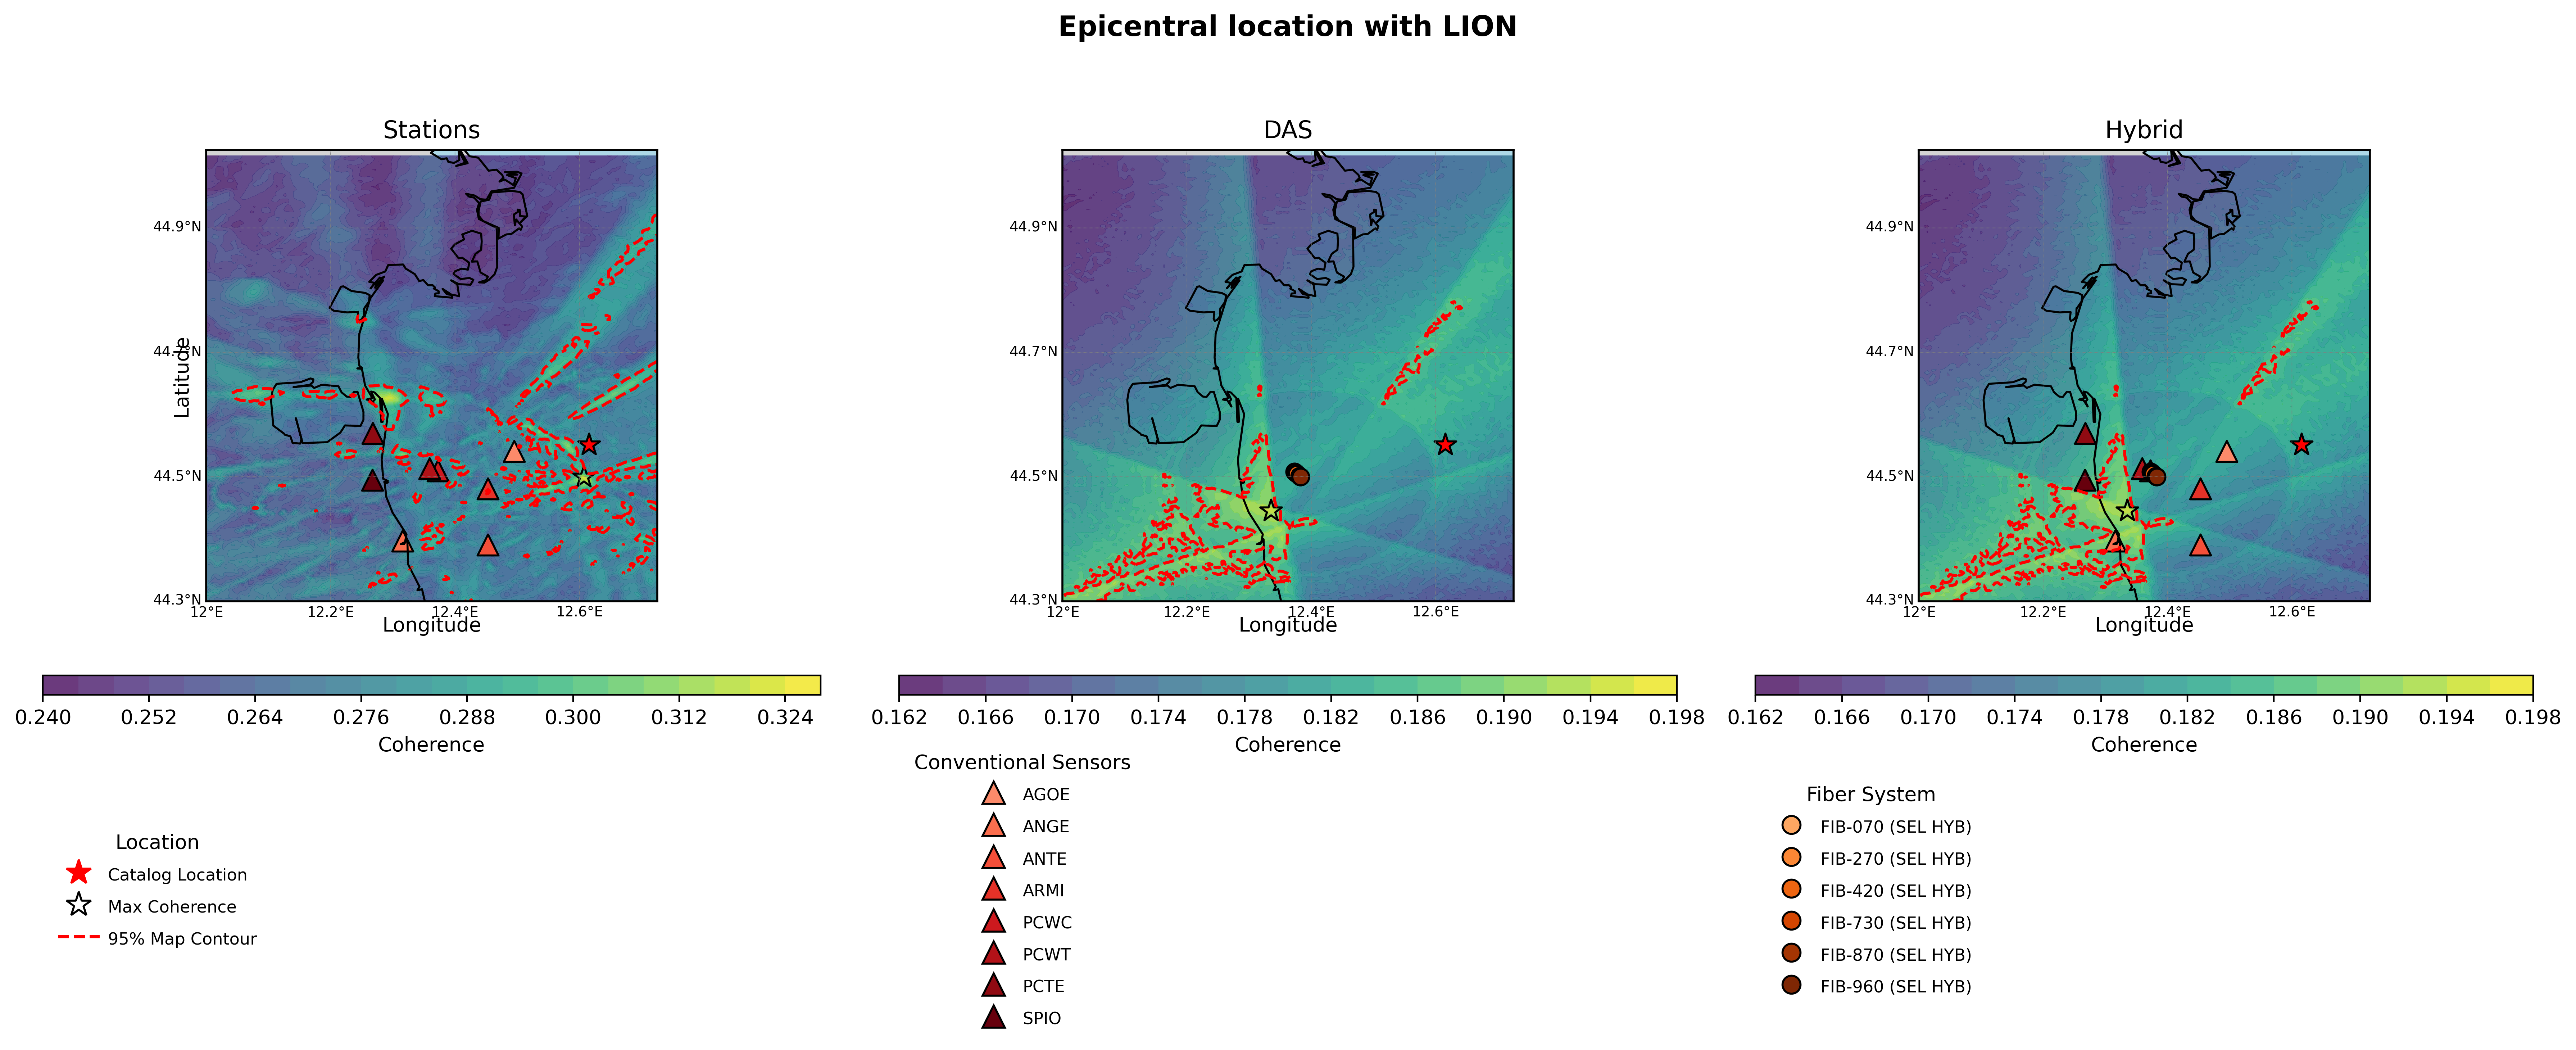

In [7]:
import numpy as np
import os

stations = {
    "AGOE": (44.5409, 12.4951),
    "ANGE": (44.3972, 12.3156),
    "ANTE": (44.3908, 12.4531),
    "ARMI": (44.4806, 12.4528),
    "PCWC": (44.5097, 12.3724),
    "PCWT": (44.5131, 12.3589),
    "PCTE": (44.5700, 12.2677),
    "SPIO":  (44.4949, 12.2671)
}

das_hyb = {
    "FIB-070 (SEL HYB)": (44.5083, 12.3730),
    "FIB-270 (SEL HYB)": (44.5063, 12.3749),
    "FIB-420 (SEL HYB)": (44.5046, 12.3770),
    "FIB-730 (SEL HYB)": (44.5012, 12.3813),
    "FIB-870 (SEL HYB)": (44.5002, 12.3825),
    "FIB-960 (SEL HYB)": (44.4999, 12.3829)
}

base_dir = "/home/emanuele/data/emanuele/loki-das/ravenna/output"
geometry_das = "/home/emanuele/data/emanuele/loki-das/Traveltimes/ravenna/stations_ravenna_total_geom.dat"

ref_lat = 44.30
ref_lon = 12.00


name = 'ww2_bomb'
#name = 'closest_event'

base_dir = "/home/emanuele/data/emanuele/loki-das/ravenna/output/" + name 


earthquake_location = (44.5517, 12.6152, 0)

nx = 161
ny = 161
nz = 101
dx = 0.5
dz = 0.5

earthquake_x, earthquake_y = convert_to_cartesian(earthquake_location[0], earthquake_location[1], ref_lat, ref_lon)
earthquake_z = earthquake_location[2]

def select_highest_coherence_file(folder):
    folder_name = os.path.basename(folder.rstrip('/'))
    loc_filename = f"{folder_name}.loc"
    loc_file = os.path.join(folder, loc_filename)
    
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Catalogue file not found in {folder}: {loc_file}")
    
    catalog = np.loadtxt(loc_file)
    print(catalog)
    coherence = catalog[:,4]
    max_idx = np.argmax(coherence)
    
    # Use folder_name in .npy filename instead of hardcoded 'fibre'
    npy_file = os.path.join(folder, f"corrmatrix_trial_{max_idx}_{folder_name}.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f".npy file not found: {npy_file}")
    
    return npy_file

stations_folder = os.path.join(base_dir, "stations")
fiber_folder = os.path.join(base_dir, "fiber")  # changed from 'das' to 'fiber'
hyb_folder = os.path.join(base_dir, "hybrid")

stations_file = select_highest_coherence_file(stations_folder)
fiber_file = select_highest_coherence_file(fiber_folder)  # updated variable name accordingly
hyb_file = select_highest_coherence_file(hyb_folder)

print("Selected files:")
print("Stations:", stations_file)
print("Fiber:", fiber_file)
print("Hybrid:", hyb_file)


# --- Load and reshape correlation matrices ---
corrmatrix_sta = np.load(stations_file).reshape((nx, ny, nz))
corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
corrmatrix_hyb = np.load(hyb_file).reshape((nx, ny, nz))

print("Shape of correlation matrices:", corrmatrix_sta.shape, corrmatrix_das.shape, corrmatrix_hyb.shape)

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 80, nx), np.linspace(0, 80, ny))

lat_range = (ref_lat, ref_lat + nx*dx/111)
lon_range = (ref_lon, ref_lon + ny*dx/111)

plot_geographical_map_multiview(
    ref_lat, ref_lon, stations, geometry_das, das_hyb, earthquake_location,
    [corrmatrix_sta, corrmatrix_das, corrmatrix_hyb],
    cartesian_grid_x, cartesian_grid_y,
    lat_range, lon_range,
    [stations_file, fiber_file, hyb_file],  # files
    ['Stations', 'DAS', 'Hybrid']        # titles
)


## 3D PLOTS 

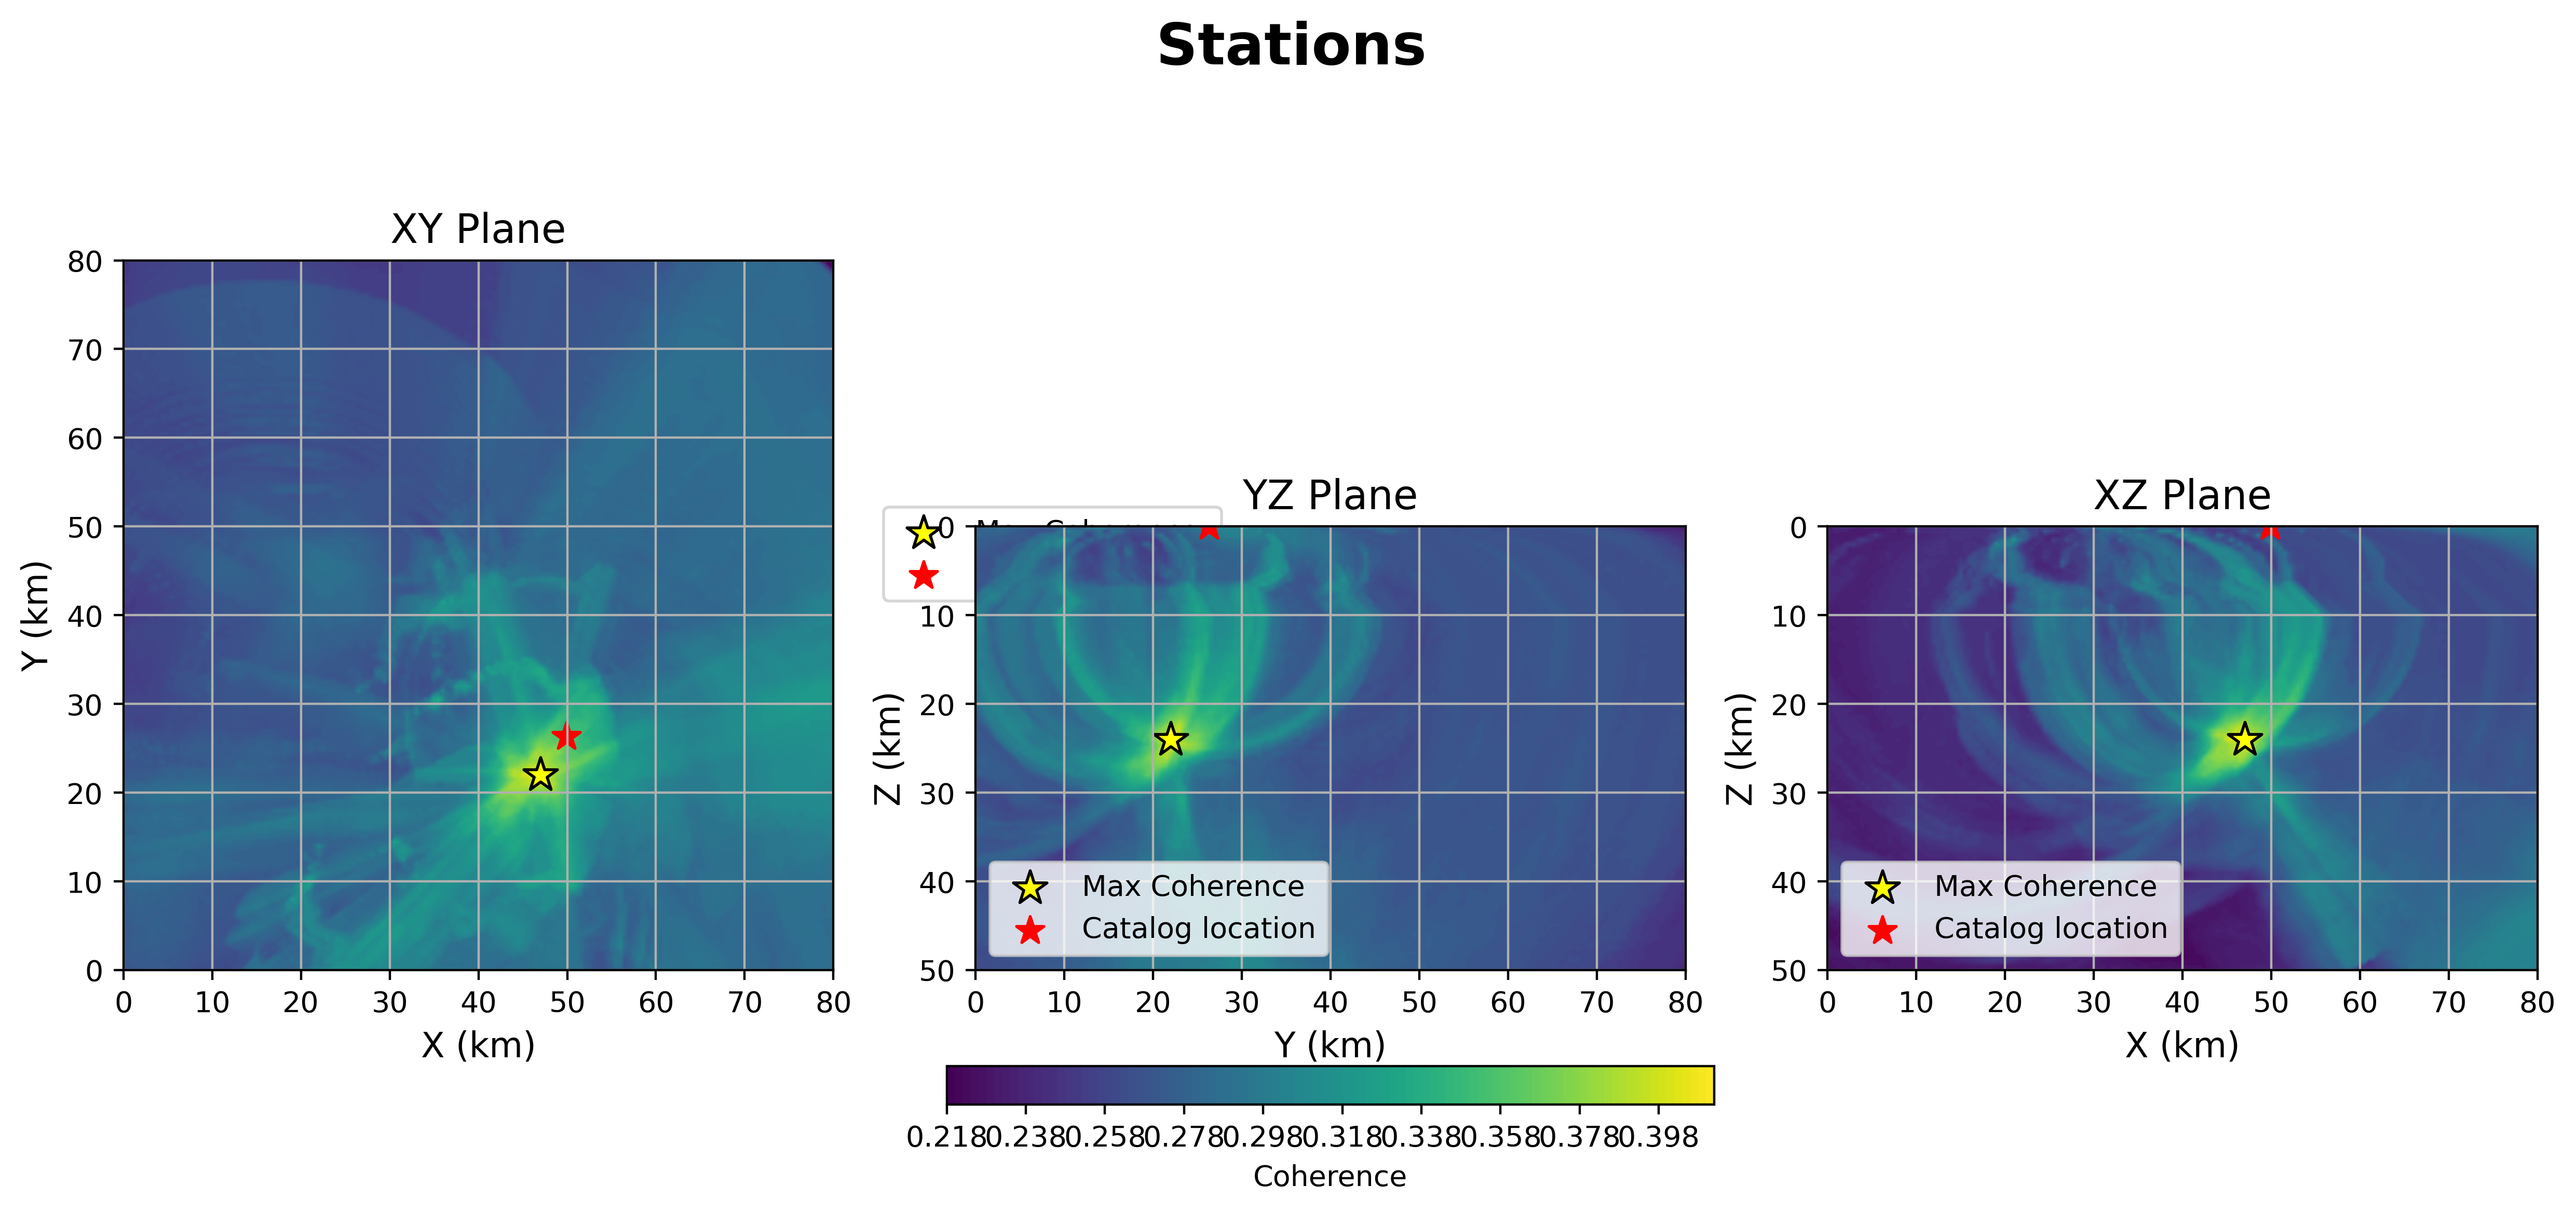

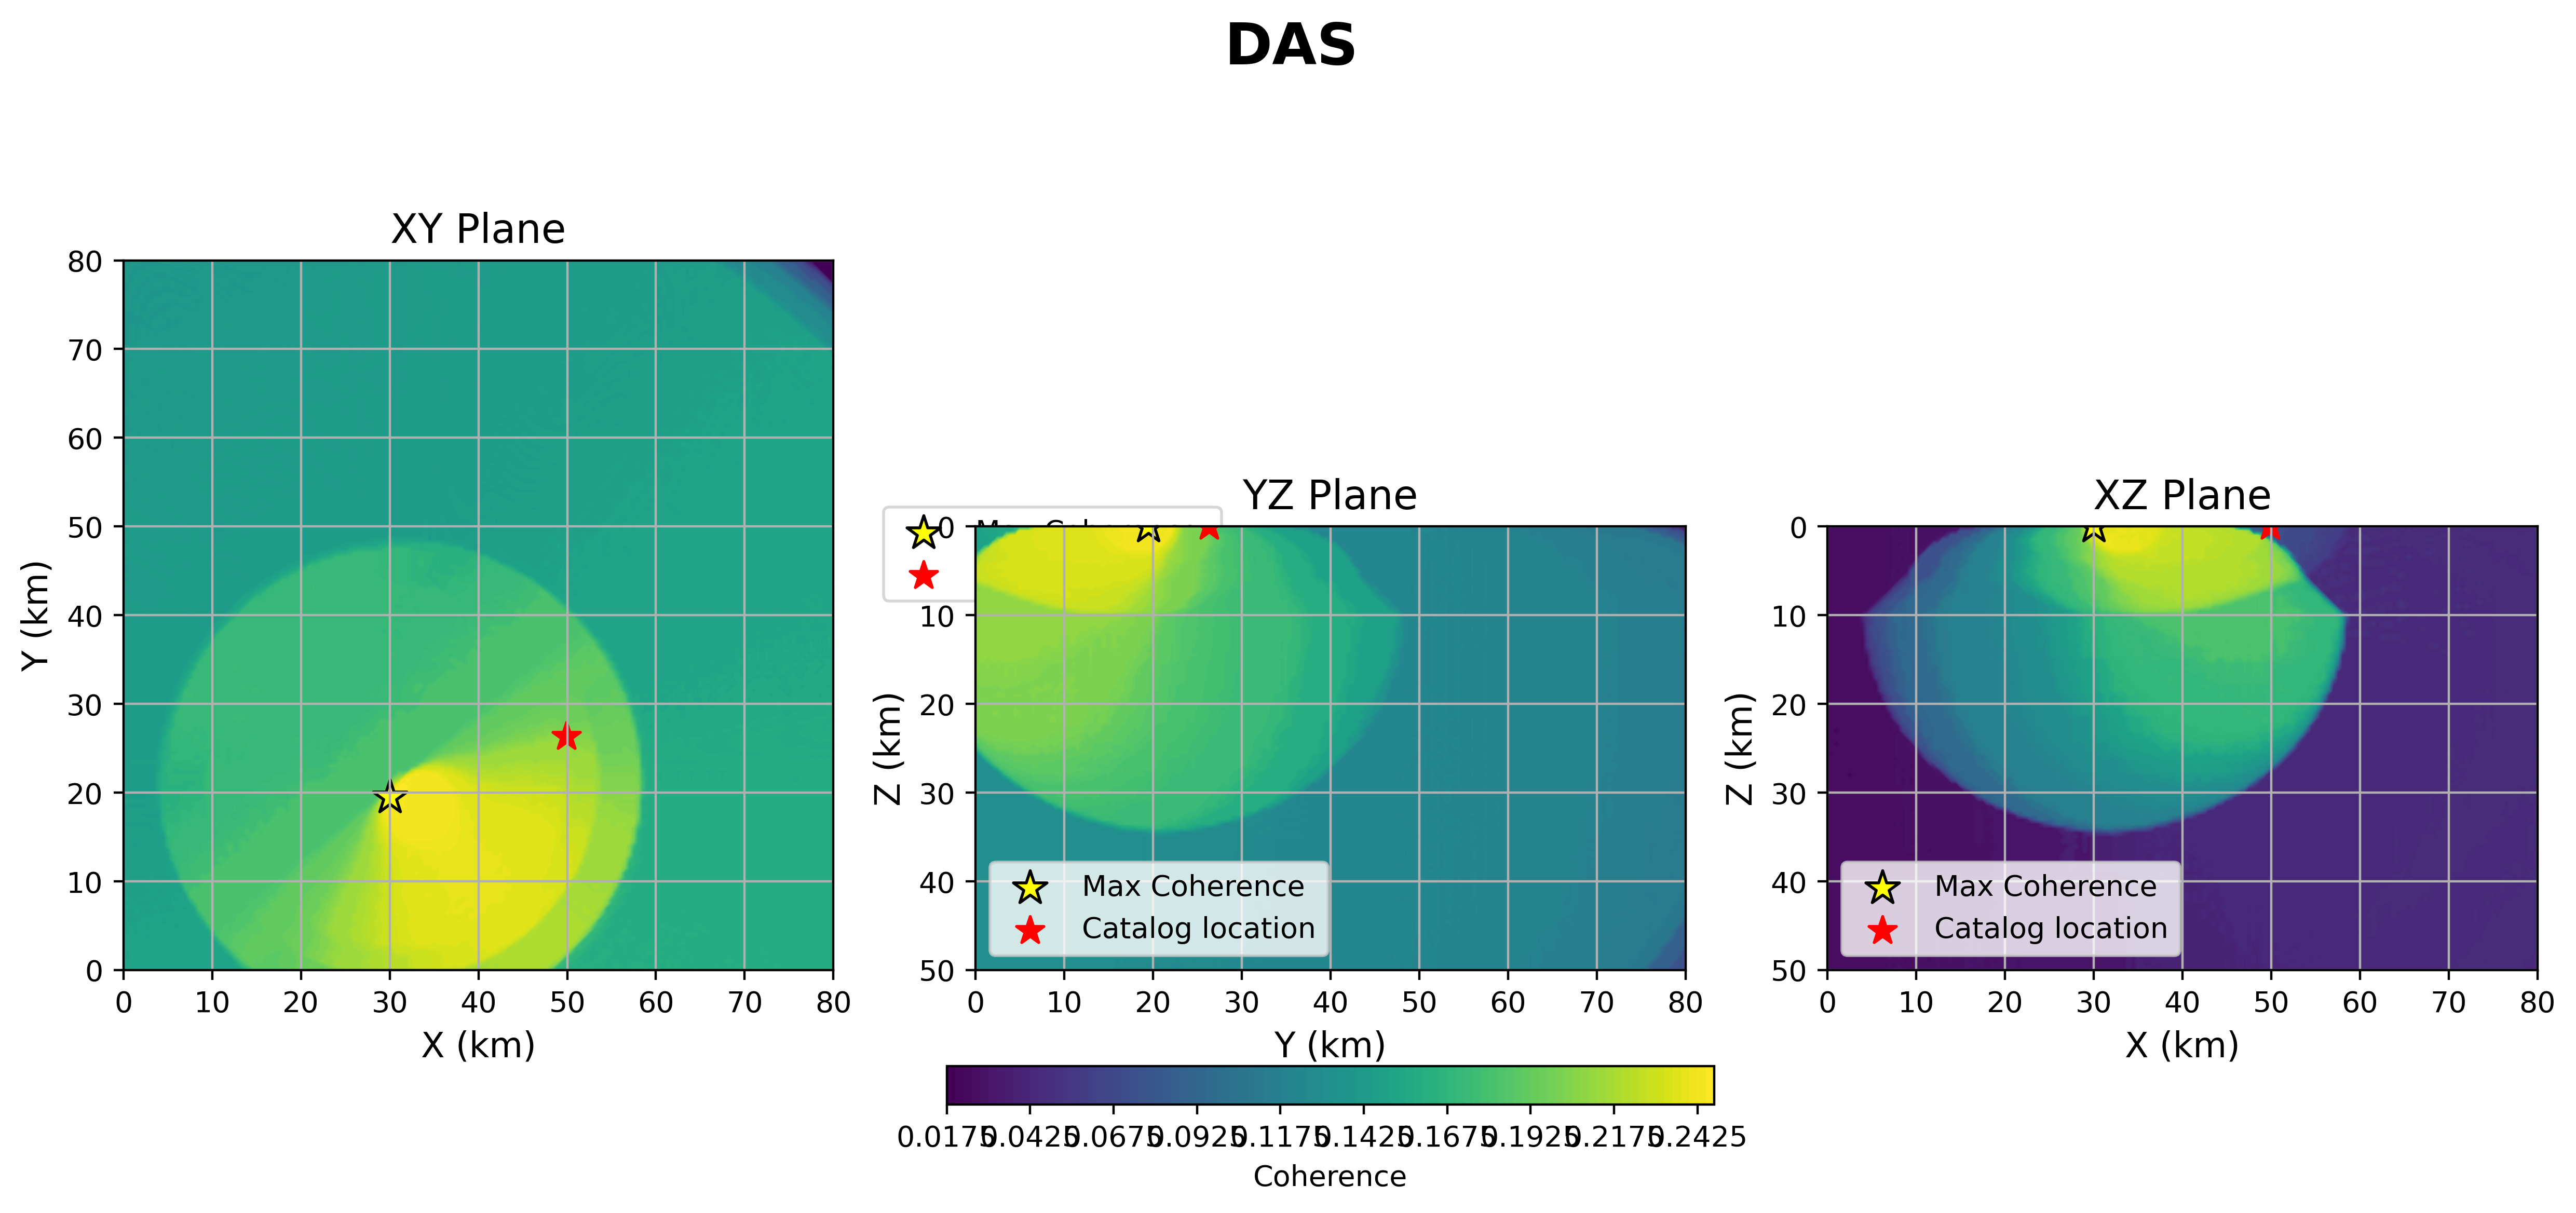

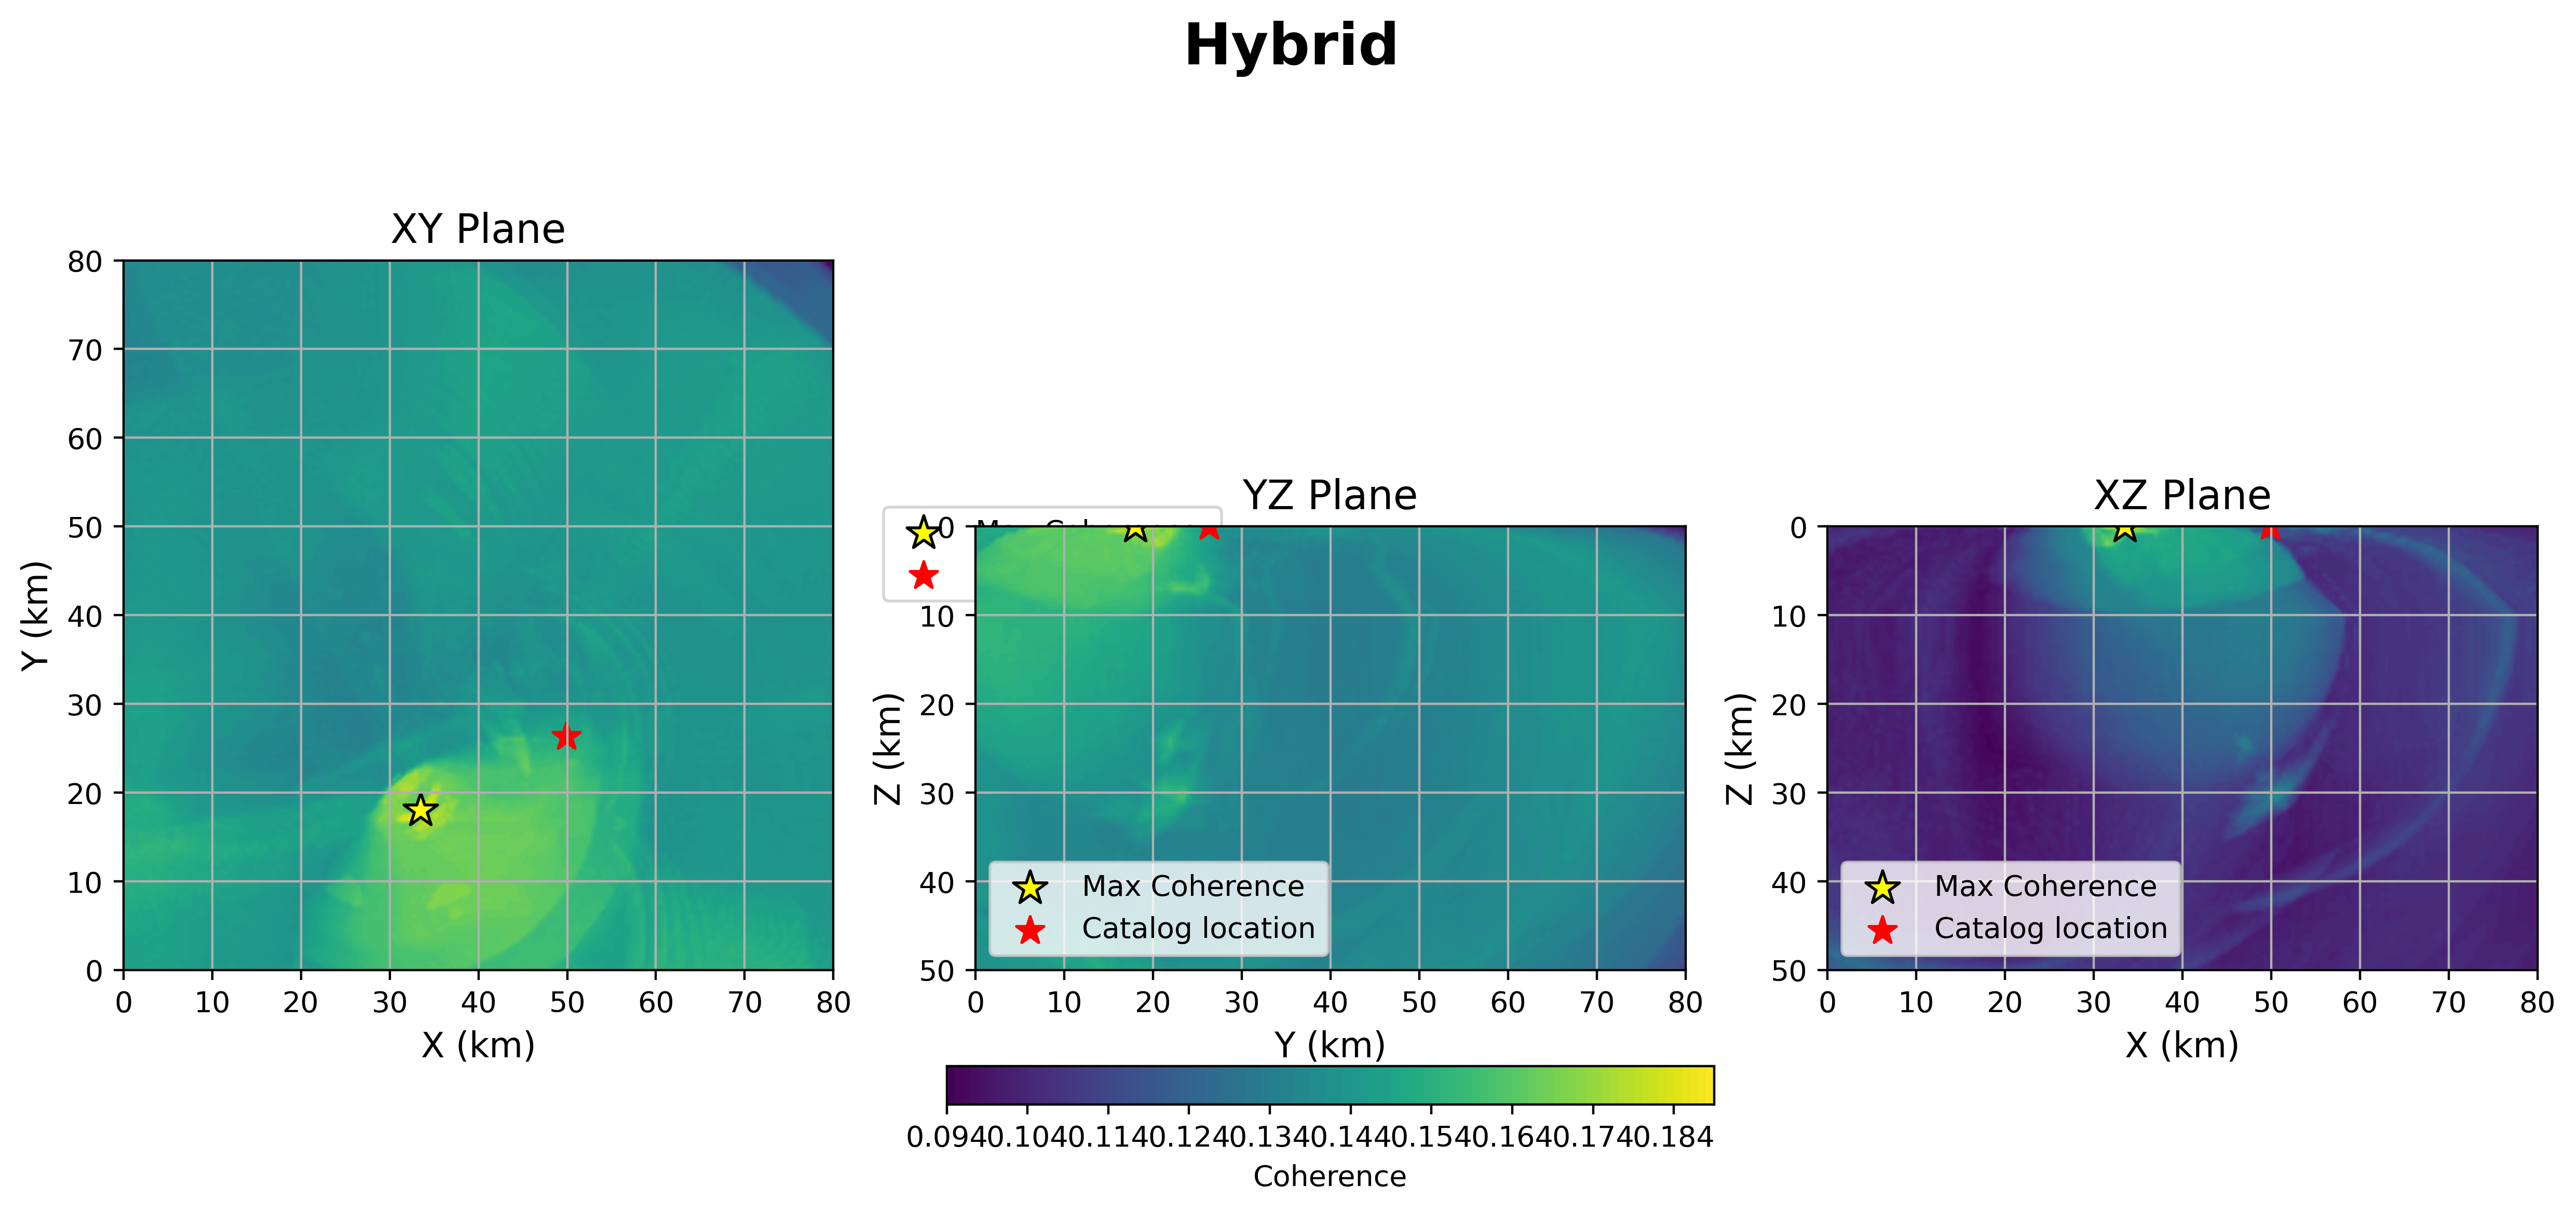

In [36]:
import numpy as np
import os

# Assuming convert_to_cartesian and coherence_plot_3d are already defined

# Parameters from your improved cell
nx = 161
ny = 161
nz = 101
dx = 0.5
dz = 0.5

ref_lat = 44.30
ref_lon = 12.00

earthquake_location = (44.5517, 12.6152, 0)
earthquake_x, earthquake_y = convert_to_cartesian(earthquake_location[0], earthquake_location[1], ref_lat, ref_lon)
earthquake_z = earthquake_location[2]

# Create coordinate axes based on grid dimensions and spacing
x = np.arange(0, nx * dx, dx)
y = np.arange(0, ny * dx, dx)
z = np.arange(0, nz * dz, dz)

# Files and titles from previous selection
files = [stations_file, fiber_file, hyb_file]
titles = ['Stations', 'DAS', 'Hybrid']

# Loop through each correlation matrix file, load, reshape, and plot coherence
for i in range(3):
    corrmatrix = np.load(files[i])
    corrmatrix = np.reshape(corrmatrix, (nx, ny, nz))
    
    coherence_plot_3d(
        corrmatrix,
        files=files[i],
        title=titles[i],
        xax=x,
        yax=y,
        zax=z,
        itrial=1,
        earthquake_x=earthquake_x,
        earthquake_y=earthquake_y,
        earthquake_z=earthquake_z,
        clip=1
    )
